In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import subprocess
import subprocess
import tempfile
import os
from matplotlib.patches import Patch

sns.set_style('whitegrid')
net_colors = ["#ff2e2e", "#762fb5", "#30df2f", "#30acac", "#b661ff", "#f4f42f"]
sns.set_palette(sns.color_palette(net_colors))
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 26,     # subplot title
    'axes.labelsize': 20,     # axis label
    'xtick.labelsize': 20,    # tick label
    'ytick.labelsize': 20
})
network_colors = {
    'DMN': "#fb2e2e", 'VAN': '#40cce9', 'LANG': '#40cce9', 'TPOLE': '#2e87ae',
    'AUD': '#ce8fff', 'AMN': '#8a2edb', 'DAN': '#2efe2e',  'FP': '#ffff2e', 
    'MTL': '#89fd89', 'PMN': '#2e2eff', 'PON': "#c3bfbfff", 'SAL': '#2e2e2e',
    'SMd': '#8fffff', 'SMl': '#ffa12e', 'VIS': '#2e2eb3', 'MTL': '#89fd89'
    }


In [10]:
def radar_plot(df, comm_col, colors=["#762fb5", "#ff2e2e", "#30df2f", "#30acac", "#b661ff", "#f4f42f"], Pos=True):
    """
    Create radar plots for left and right hemisphere data across communities,
    with a consistent scale across all subplots.

    Parameters:
    - df: DataFrame with columns as features and rows as subjects
    - comm_col: Name of the column indicating community assignment
    """
    # Identify left and right hemisphere columns
    # Create labels 
    left_cols = [col for col in df.columns if '_L_' in col and col.endswith('_resid') and 'full' not in col]
    right_cols = [col for col in df.columns if '_R_' in col and col.endswith('_resid') and 'full' not in col]
    labels_left = [col.split('_L_')[0] for col in left_cols]
    labels_right = [col.split('_R_')[0] for col in right_cols]
    labels_left = [label.split('_')[-1] + '_' + label.split('_')[0] for label in labels_left]
    labels_right = [label.split('_')[-1] + '_' + label.split('_')[0] for label in labels_right]
    print(labels_left)
    print(labels_right)

    replacements = [('left_VAN', 'LANG'),
                    ('right_VAN', 'VAN'),
                    ('left_CO', 'L_AMN'),
                    ('right_CO', 'R_AMN'),
                    ('_Sal', '_SAL'),
                    ('_Tpole', '_TPOLE'),
                    ('_Vis', '_VIS'),
                    ('_Aud', '_AUD'),
                    ('left', 'L'),
                    ('right', 'R'),
                ]

    for old, new in replacements:
        labels_left = [label.replace(old, new) for label in labels_left]
        labels_right = [label.replace(old, new) for label in labels_right]

    # Compute angles
    angles_left = np.linspace(0, 2 * np.pi, len(left_cols), endpoint=False).tolist()
    angles_left += angles_left[:1]
    angles_right = np.linspace(0, 2 * np.pi, len(right_cols), endpoint=False).tolist()
    angles_right += angles_right[:1]

    # Function to compute mean radar profile per community
    def get_mean_profile(df, columns, community_id):
        profile = df[df[comm_col] == community_id][columns].mean().tolist()
        profile += profile[:1]  # close the radar
        if Pos:
            profile = [max(0, val) for val in profile]
        return profile

    # Compute global min/max for scaling
    all_profiles_left = []
    all_profiles_right = []
    communities = df[comm_col].unique()

    for comm in communities:
        all_profiles_left.append(get_mean_profile(df, left_cols, comm)[:-1])
        all_profiles_right.append(get_mean_profile(df, right_cols, comm)[:-1])
    if Pos:
        global_min = 0
    else:
        global_min = min(np.min(all_profiles_left), np.min(all_profiles_right))
    global_max = max(np.max(all_profiles_left), np.max(all_profiles_right))

    # Plot
    fig, axs = plt.subplots(len(communities), 2, subplot_kw=dict(polar=True), figsize=(14, len(communities)*7))

    # Order communities by mean DMN_left_L_fz_resid
    dmn_left_col = 'DMN_left_L_fz_resid'
    if dmn_left_col in df.columns:
        dmn_means = df.groupby(comm_col)[dmn_left_col].mean()
        ordered_communities = dmn_means.sort_values().index.tolist()
    else:
        ordered_communities = sorted(communities, key=lambda x: int(x))
    communities = [comm for comm in ordered_communities if comm in df[comm_col].unique()]
    
    for i, comm in enumerate(communities):
        # Left hemisphere
        profile_left = get_mean_profile(df, left_cols, comm)
        ax_left = axs[i, 0]
        ax_left.plot(angles_left, profile_left, color=colors[i % len(colors)], linewidth=2, linestyle='solid')
        ax_left.fill(angles_left, profile_left, color=colors[i % len(colors)], alpha=0.25)
        if i == 0:
            ax_left.set_title(f'Left pMTG FC', size=24, pad=16)
        elif i == len(communities) - 1:
            ax_left.set_title(f'Left pMTG FC', size=24, pad=16)
        ax_left.set_xticks(angles_left[:-1])
        ax_left.set_xticklabels(labels_left, size=14)
        ax_left.tick_params(axis='y', labelsize=12)
        ax_left.set_ylim(0, 0.3)
        for label in ax_left.get_xticklabels():
            label.set_zorder(10)

        # Right hemisphere
        profile_right = get_mean_profile(df, right_cols, comm)
        ax_right = axs[i, 1]
        ax_right.plot(angles_right, profile_right, color=colors[i % len(colors)], linewidth=2, linestyle='solid')
        ax_right.fill(angles_right, profile_right, color=colors[i % len(colors)], alpha=0.25)
        if i == 0:
            ax_right.set_title(f'Right pMTG FC', size=24, pad=16)
        elif i == len(communities) - 1:
            ax_right.set_title(f'Right pMTG FC', size=24, pad=16)
        ax_right.set_xticks(angles_right[:-1])
        ax_right.set_xticklabels(labels_right, size=14)
        ax_right.tick_params(axis='y', labelsize=12)
        ax_right.set_ylim(0, 0.3)
        for label in ax_right.get_xticklabels():
            label.set_zorder(10)

    plt.tight_layout()
    plt.show()

In [11]:
def radar_plot_single(df, comm_col, subtype, title, color="#ff2e2e", Pos=True):
    """
    Create radar plots for left and right hemisphere data for a single community.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with columns as features and rows as subjects.
    comm_col : str
        Name of the column indicating community assignment.
    community_id : int or str
        The community ID to plot.
    title : str
        Title for the figure.
    color : str, optional
        Matplotlib color for the radar lines and fill.
    Pos : bool, optional
        If True, negative values are set to 0 before plotting.
    """

    # --- Identify hemisphere columns ---
    left_cols = [col for col in df.columns if '_L_' in col and col.endswith('_resid') and 'full' not in col]
    right_cols = [col for col in df.columns if '_R_' in col and col.endswith('_resid') and 'full' not in col]

    # --- Construct labels ---
    labels_left = [col.split('_L_')[0] for col in left_cols]
    labels_right = [col.split('_R_')[0] for col in right_cols]
    labels_left = [label.split('_')[-1] + '_' + label.split('_')[0] for label in labels_left]
    labels_right = [label.split('_')[-1] + '_' + label.split('_')[0] for label in labels_right]

    replacements = [
        ('left_VAN', 'LANG'),
        ('right_VAN', 'VAN'),
        ('left_CO', 'L_AMN'),
        ('right_CO', 'R_AMN'),
        ('_Sal', '_SAL'),
        ('_Tpole', '_TPOLE'),
        ('_Vis', '_VIS'),
        ('_Aud', '_AUD'),
        ('left', 'L'),
        ('right', 'R'),
    ]
    for old, new in replacements:
        labels_left = [lbl.replace(old, new) for lbl in labels_left]
        labels_right = [lbl.replace(old, new) for lbl in labels_right]

    # --- Compute angles for radar axes ---
    angles_left = np.linspace(0, 2 * np.pi, len(left_cols), endpoint=False).tolist()
    angles_left += angles_left[:1]
    angles_right = np.linspace(0, 2 * np.pi, len(right_cols), endpoint=False).tolist()
    angles_right += angles_right[:1]

    # --- Compute mean profiles for the selected community ---
    def get_mean_profile(columns):
        prof = df[df[comm_col] == subtype][columns].mean().tolist()
        prof += prof[:1]
        if Pos:
            prof = [max(0, v) for v in prof]
        return prof

    profile_left = get_mean_profile(left_cols)
    profile_right = get_mean_profile(right_cols)

    # --- Global scaling (based on all data) ---
    all_left = df[left_cols].to_numpy().flatten()
    all_right = df[right_cols].to_numpy().flatten()
    global_min = 0 if Pos else min(all_left.min(), all_right.min())
    global_max = max(all_left.max(), all_right.max())

    # --- Create figure with two panels ---
    fig, axs = plt.subplots(1, 2, subplot_kw=dict(polar=True), figsize=(10.5, 7))
    fig.suptitle(f'{title}', size=22, y=0.9)

    # Left hemisphere
    axL = axs[0]
    axL.plot(angles_left, profile_left, color=color, linewidth=2)
    axL.fill(angles_left, profile_left, color=color, alpha=0.25)
    axL.set_xticks(angles_left[:-1])
    axL.set_xticklabels(labels_left, size=10)
    axL.set_ylim(global_min, global_max)
    axL.set_title(f"Left pMTG FC", size=14, pad=12)
    axL.set_ylim(0, 0.3)
    axL.tick_params(axis='y', labelsize=8)

    # Right hemisphere
    axR = axs[1]
    axR.plot(angles_right, profile_right, color=color, linewidth=2)
    axR.fill(angles_right, profile_right, color=color, alpha=0.25)
    axR.set_xticks(angles_right[:-1])
    axR.set_xticklabels(labels_right, size=10)
    axR.set_ylim(global_min, global_max)
    axR.set_title(f"Right pMTG FC", size=14, pad=12)
    axR.set_ylim(0, 0.3)
    axR.tick_params(axis='y', labelsize=8)

    # Adjust layout to use whitespace fully
    fig.subplots_adjust(wspace=0.4, left=0.05, right=0.95, top=0.9, bottom=0.05)
    plt.show()


In [12]:
def plot_label_for(base_net, net_hemi):
    b = base_net.upper()
    nh = net_hemi.lower()

    if b == "CO":
        b = "AMN"
    if b == "SMD":
        b = "SMd"
    if b == "SML":
        b = "SMl"
    if b == "TPOLE":
        b = "TPOLE"

    if b == "VAN" and nh == "left":
        return "LANG"
    if b == "VAN" and nh == "right":
        return "VAN"

    return b


def x_tick_label_for(base_net):
    b = base_net.upper()
    if b == "VAN":
        return "LANG/VAN"
    if b == "CO":
        return "AMN"
    if b == "SMD":
        return "SMd"
    if b == "SML":
        return "SMl"
    if b == "TPOLE":
        return "TPOLE"
    return b


def bar_plot(df, comm_col):
    network_colors = {
        'DMN': "#fb2e2e",
        'VAN': '#40cce9',
        'LANG': '#40cce9',
        'TPOLE': '#2e87ae',
        'AUD': '#ce8fff',
        'AMN': '#8a2edb',
        'DAN': '#2efe2e',
        'FP': '#ffff2e',
        'MTL': '#89fd89',
        'PMN': '#2e2eff',
        'PON': "#ebebeb",
        'SAL': '#2e2e2e',
        'SMd': '#8fffff',
        'SMl': '#ffa12e',
        'VIS': '#2e2eb3'
    }

    network_cols = [c for c in df.columns if c.endswith('_fz_resid') and 'full' not in c]

    dmn_left_col = 'DMN_left_L_fz_resid'
    if dmn_left_col not in df.columns:
        return

    comm_means = df.groupby(comm_col)[network_cols].mean(numeric_only=True)
    comm_serrs = df.groupby(comm_col)[network_cols].sem(numeric_only=True)
    dmn_means = df.groupby(comm_col)[dmn_left_col].mean()

    ordered_comms = dmn_means.sort_values(ascending=False).index.tolist()
    if len(ordered_comms) < 2:
        return
    
    # get number of subjects in each community
    n_map = {}
    for comm_id, count in df[comm_col].value_counts().items():
        n_map[comm_id] = count

    subtype_names = ['Default-Mode Subtype', 'Control-Network Subtype']
    comm_means = comm_means.rename(index={
        ordered_comms[0]: subtype_names[0],
        ordered_comms[1]: subtype_names[1],
    }).loc[subtype_names]

    comm_serrs = comm_serrs.rename(index={
        ordered_comms[0]: subtype_names[0],
        ordered_comms[1]: subtype_names[1],
    }).loc[subtype_names]

    # map number of subjects to subtype names
    n_map = {}
    for comm_id, count in df[comm_col].value_counts().items():
        if comm_id == ordered_comms[0]:
            n_map[subtype_names[0]] = count
        elif comm_id == ordered_comms[1]:
            n_map[subtype_names[1]] = count

    parsed = []
    for col in comm_means.columns:
        parts = col.split('_')
        if len(parts) < 3:
            continue
        base_net = parts[0]
        net_hemi = parts[1]
        pmtg_hemi = parts[2]
        if net_hemi not in ('left', 'right'):
            continue
        if pmtg_hemi not in ('L', 'R'):
            continue
        parsed.append((base_net, net_hemi, pmtg_hemi, col))

    base_nets = sorted({t[0] for t in parsed})
    col_lookup = {(p, bn, nh): c for (bn, nh, p, c) in parsed}

    fig, axes = plt.subplots(
        nrows=2, ncols=2,
        figsize=(14, 8),
        sharey=True
    )

    pmtg_order = ['L', 'R']
    width = 0.38
    x = np.arange(len(base_nets))

    for r, subtype in enumerate(subtype_names):
        for c, pmtg_hemi in enumerate(pmtg_order):
            ax = axes[r, c]

            hemi_label = "Left" if pmtg_hemi == "L" else "Right"

            y_left = []
            y_right = []
            left_colors = []
            right_colors = []

            for bn in base_nets:
                col_l = col_lookup.get((pmtg_hemi, bn, 'left'))
                col_r = col_lookup.get((pmtg_hemi, bn, 'right'))

                y_left.append(comm_means.loc[subtype, col_l])
                y_right.append(comm_means.loc[subtype, col_r])

                left_key = plot_label_for(bn, 'left')
                right_key = plot_label_for(bn, 'right')

                left_colors.append(network_colors.get(left_key, '#333333'))
                right_colors.append(network_colors.get(right_key, '#333333'))

            ax.bar(
                x - width/2, y_left, width=width,
                color=left_colors, edgecolor='black', linewidth=0.6,
                hatch='\\\\',
                yerr=comm_serrs.loc[subtype, [col_lookup.get((pmtg_hemi, bn, 'left')) for bn in base_nets]].to_numpy()
            )

            ax.bar(
                x + width/2, y_right, width=width,
                color=right_colors, edgecolor='black', linewidth=0.6,
                hatch='//',
                yerr=comm_serrs.loc[subtype, [col_lookup.get((pmtg_hemi, bn, 'right')) for bn in base_nets]].to_numpy()
            )

            ax.set_title(f"{hemi_label} pMTG", fontsize=16)

            ax.set_xticks(x)
            ax.set_xticklabels(
                [x_tick_label_for(bn) for bn in base_nets],
                rotation=45, ha='right', fontsize=14
            )

            if r == 1:
                ax.set_xlabel('Network', fontsize=16)

            if c == 0:
                ax.set_ylabel('Mean Residualized FC', fontsize=16)

            ax.tick_params(axis='y', labelsize=14)

    handles = [
        Patch(facecolor='white', edgecolor='black', hatch='\\\\',
              label='Left Hemisphere', linewidth=1.0),
        Patch(facecolor='white', edgecolor='black', hatch='//',
              label='Right Hemisphere', linewidth=1.0)
    ]

    leg = fig.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5155, 0.955),
        ncol=2,
        frameon=True,
        fontsize=12,
        handlelength=2.0,
        handleheight=1.0,
        borderpad=0.4,
        labelspacing=0.6
    )
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_edgecolor('black')

    fig.subplots_adjust(
        top=0.82,
        hspace=0.62,
        left=0.07,
        right=0.98,
        bottom=0.10
    )

    top_row_top = max(axes[0, 0].get_position().y1, axes[0, 1].get_position().y1)
    bottom_row_top = max(axes[1, 0].get_position().y1, axes[1, 1].get_position().y1)

    fig.text(
        0.525, top_row_top + 0.0077,
        f"{subtype_names[0]}\n(n = {n_map[subtype_names[0]]:,})",
        ha='center', va='bottom',
        fontsize=16
    )

    fig.text(
        0.525, bottom_row_top + 0.0077,
        f"{subtype_names[1]}\n(n = {n_map[subtype_names[1]]:,})",
        ha='center', va='bottom',
        fontsize=16
    )

    plt.show()


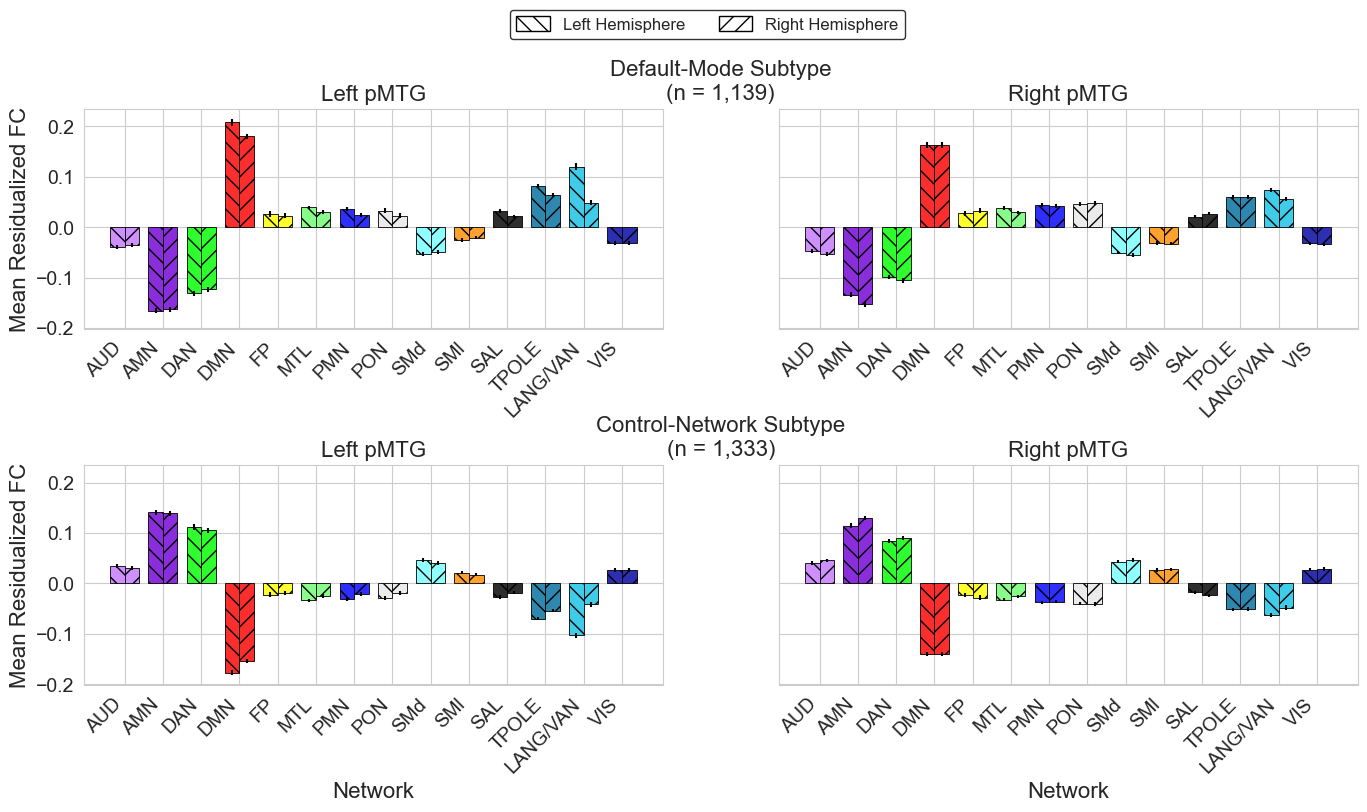

In [13]:
df = pd.read_csv('/Users/emk/Documents/Documents - Ron Weasley V/Research/Verbal-Ability/Final/midb61_meanFC_clusters_2026-04-28_11-07.csv')
bar_plot(df, 'kmeans_2_consensus')

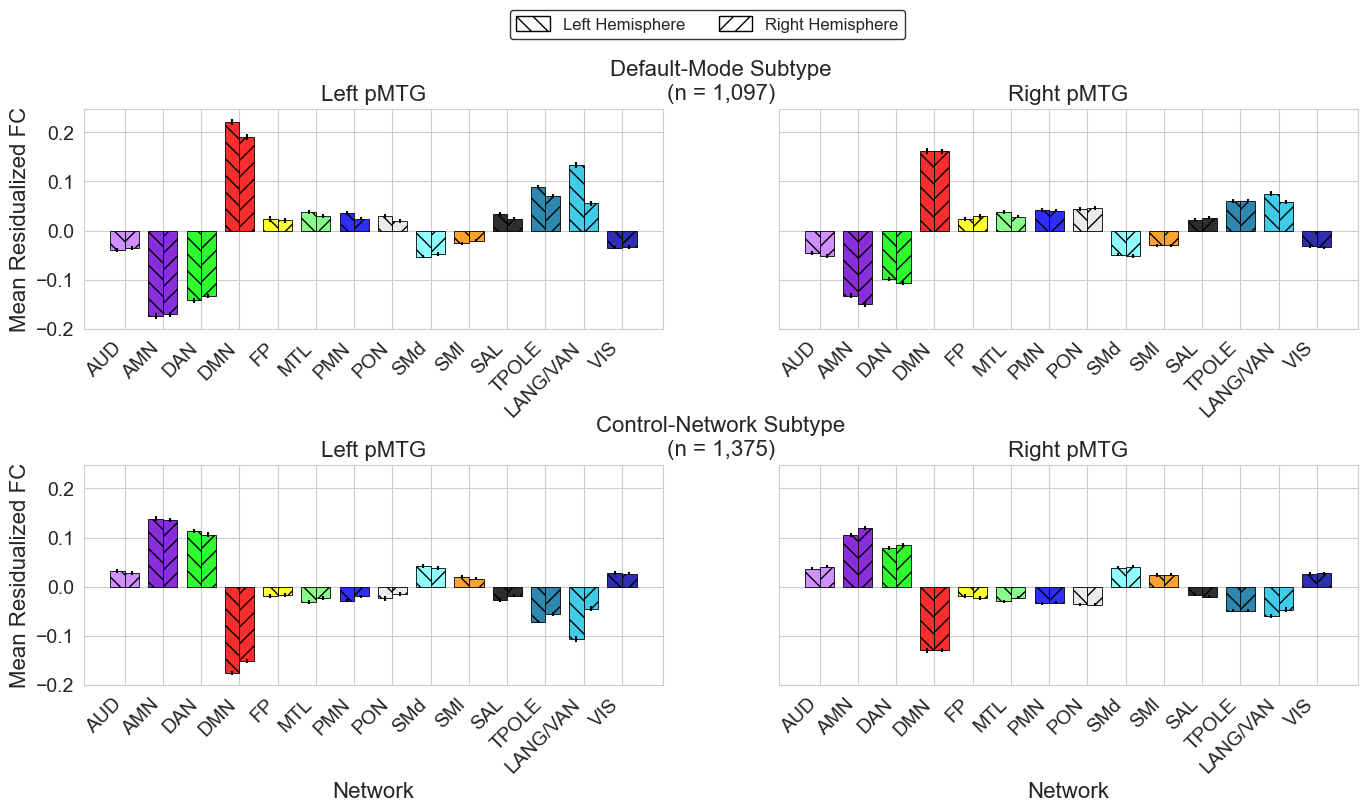

In [14]:
bar_plot(df, 'louvain_consensus')

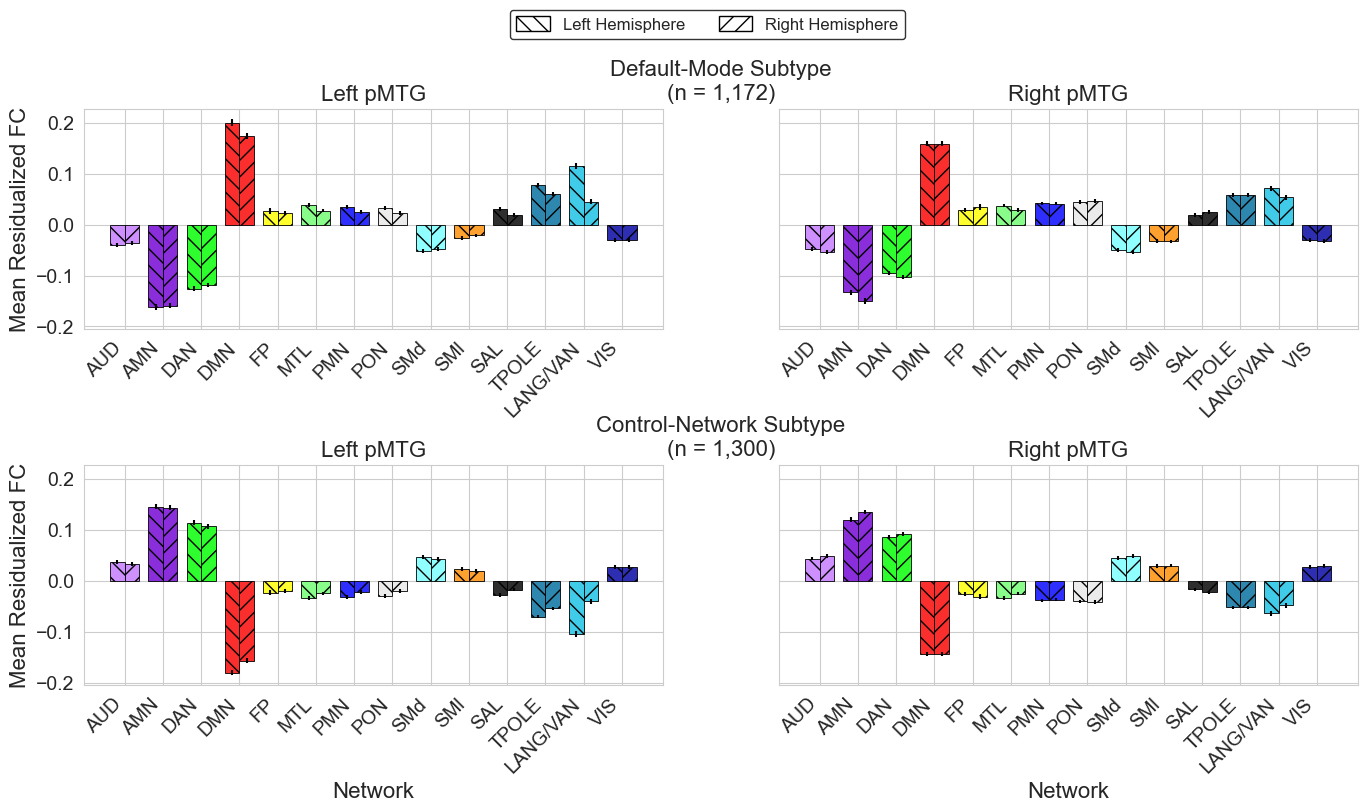

In [15]:
bar_plot(df,'infomap_community_2')

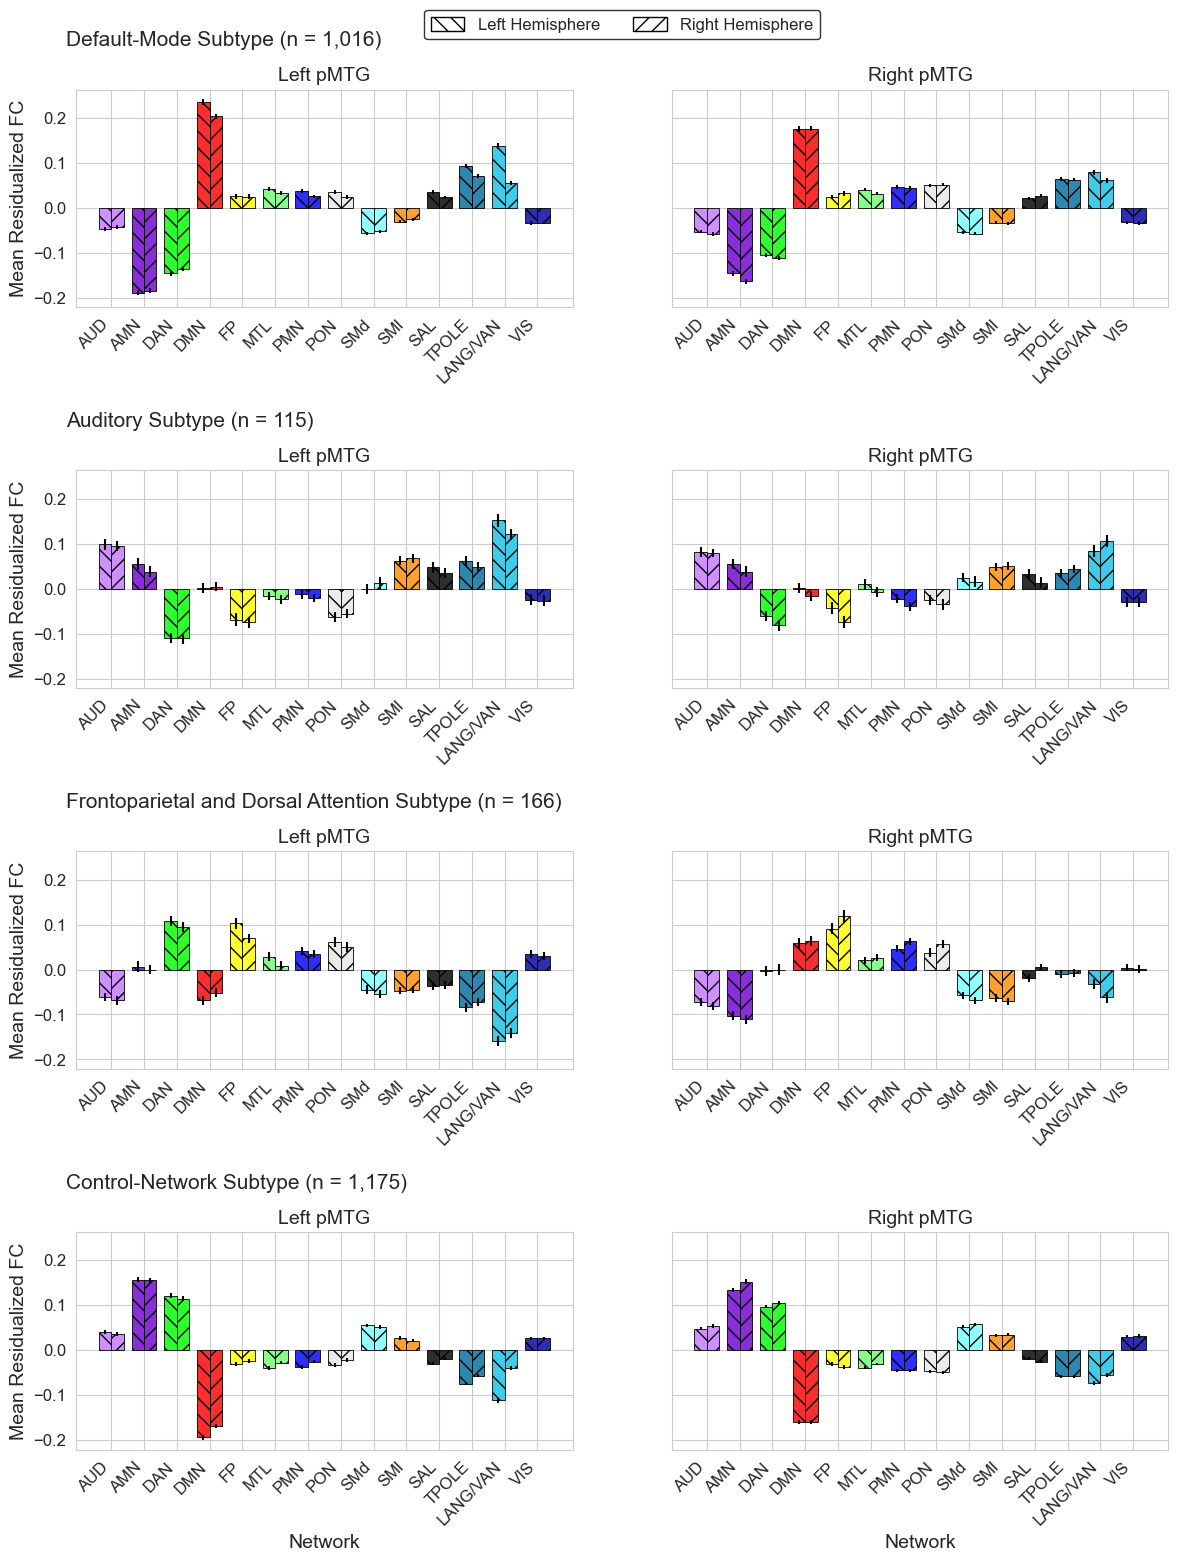

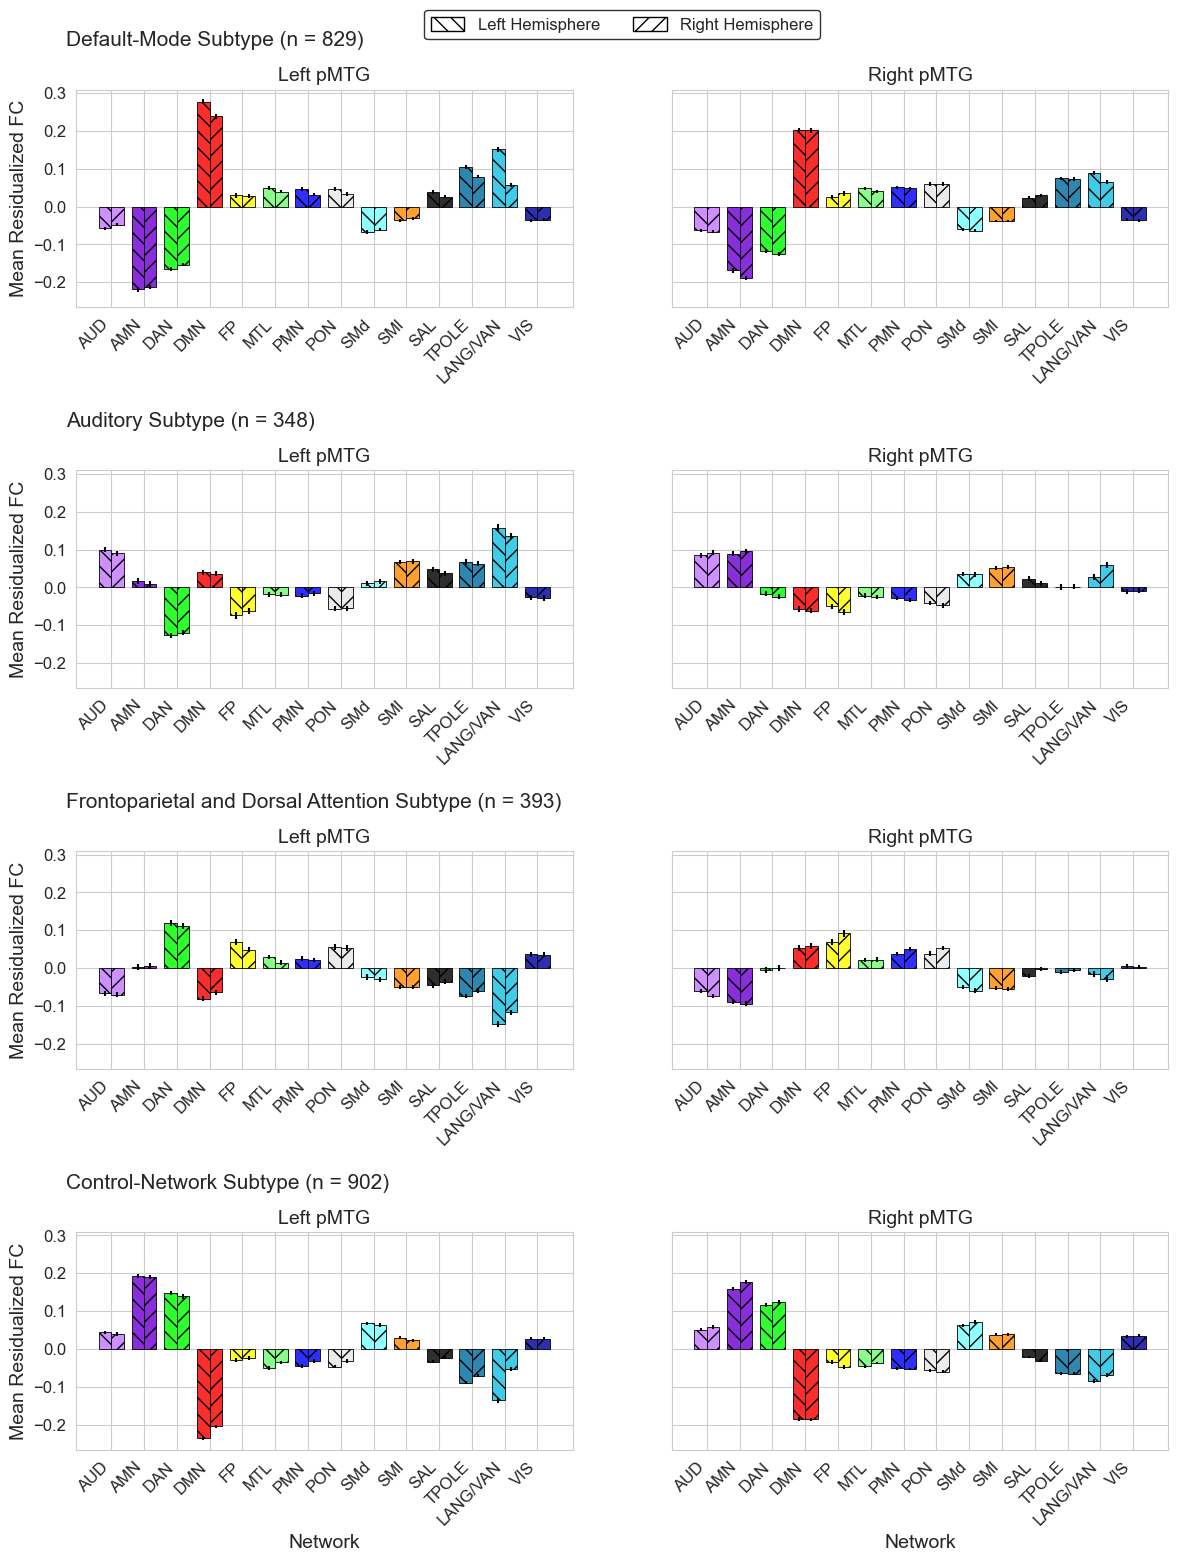

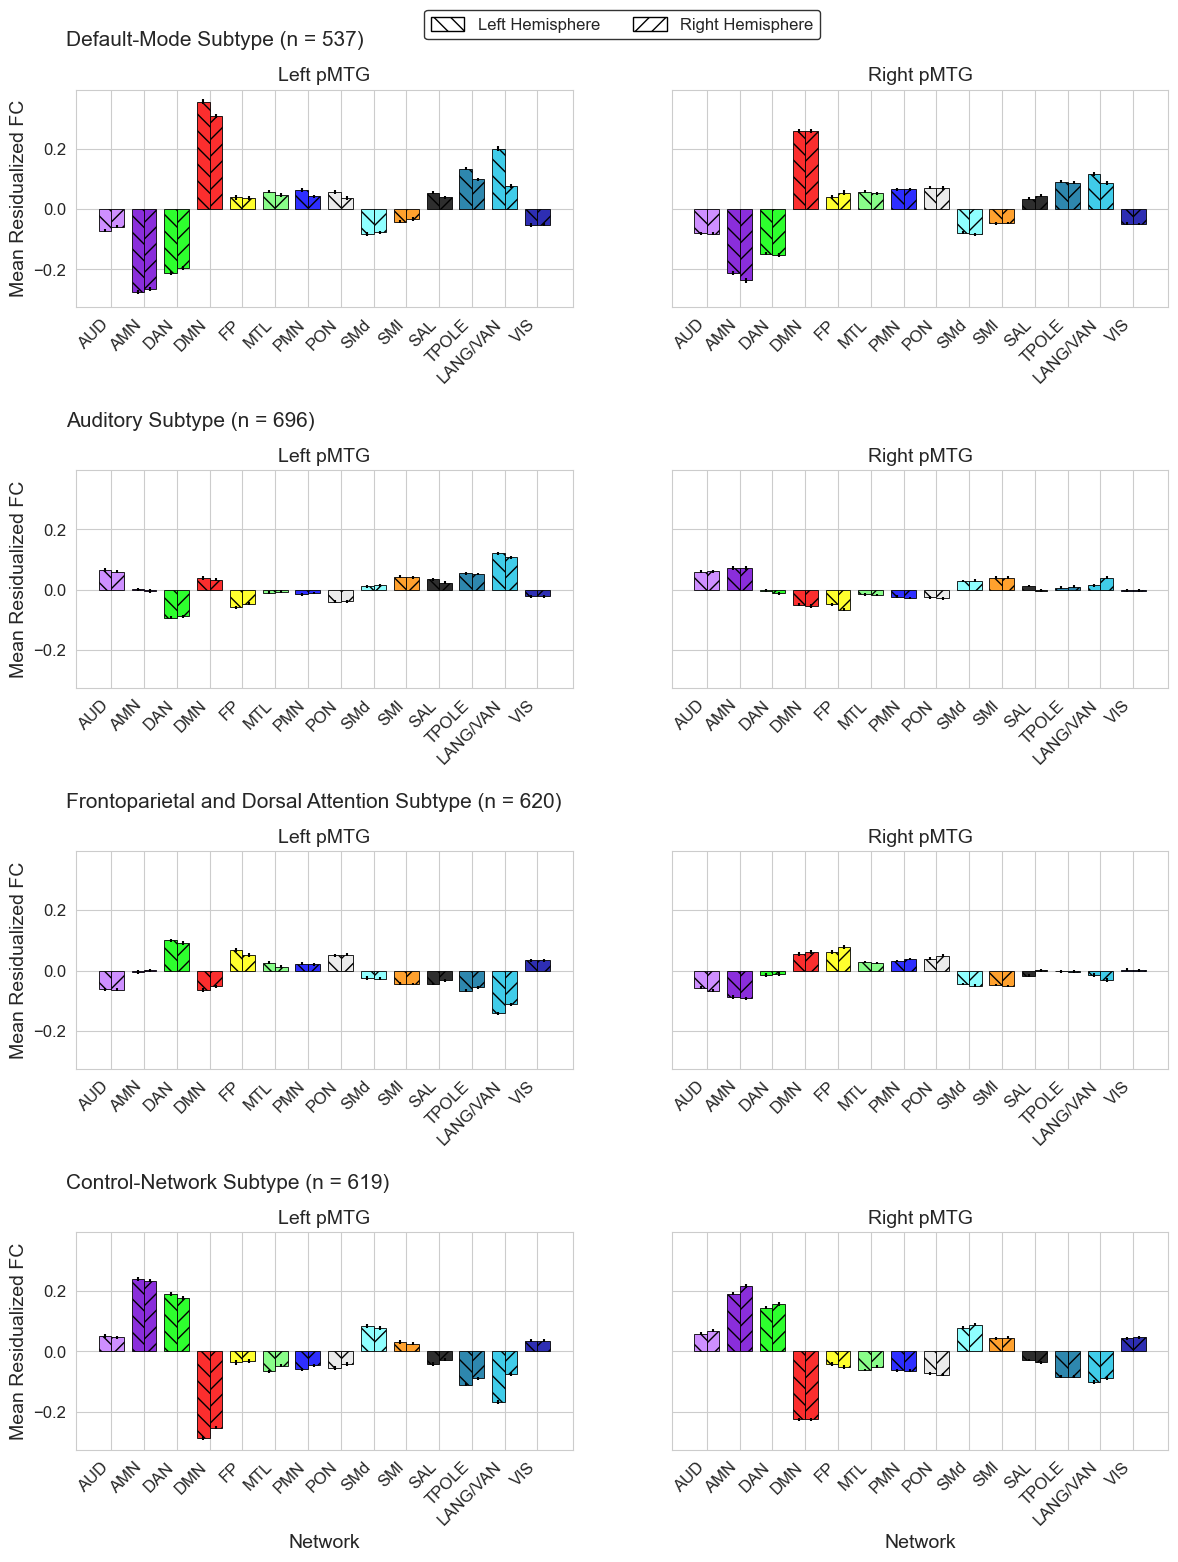

In [16]:
def bar_plot_four(df, comm_col):
    def plot_label_for(base_net, net_hemi):
        b = base_net.upper()
        nh = net_hemi.lower()

        if b == "CO":
            b = "AMN"
        if b == "SMD":
            b = "SMd"
        if b == "SML":
            b = "SMl"
        if b == "TPOLE":
            b = "TPOLE"

        if b == "VAN" and nh == "left":
            return "LANG"
        if b == "VAN" and nh == "right":
            return "VAN"

        return b

    def x_tick_label_for(base_net):
        b = base_net.upper()
        if b == "VAN":
            return "LANG/VAN"
        if b == "CO":
            return "AMN"
        if b == "SMD":
            return "SMd"
        if b == "SML":
            return "SMl"
        if b == "TPOLE":
            return "TPOLE"
        return b

    network_colors = {
        'DMN': "#fb2e2e",
        'VAN': '#40cce9',
        'LANG': '#40cce9',
        'TPOLE': '#2e87ae',
        'AUD': '#ce8fff',
        'AMN': '#8a2edb',
        'DAN': '#2efe2e',
        'FP': '#ffff2e',
        'MTL': '#89fd89',
        'PMN': '#2e2eff',
        'PON': "#ebebeb",
        'SAL': '#2e2e2e',
        'SMd': '#8fffff',
        'SMl': '#ffa12e',
        'VIS': '#2e2eb3'
    }

    network_cols = [c for c in df.columns if c.endswith('_fz_resid') and 'full' not in c]

    dmn_left_col = 'DMN_left_L_fz_resid'
    if dmn_left_col not in df.columns:
        return

    comm_means = df.groupby(comm_col)[network_cols].mean(numeric_only=True)
    comm_serrs = df.groupby(comm_col)[network_cols].sem(numeric_only=True)
    dmn_means = df.groupby(comm_col)[dmn_left_col].mean()

    ordered_comms = dmn_means.sort_values(ascending=False).index.tolist()
    if len(ordered_comms) < 4:
        return

    n_by_comm = df[comm_col].value_counts().to_dict()

    subtype_names = [
        'Default-Mode Subtype',
        'Auditory Subtype',
        'Frontoparietal and Dorsal Attention Subtype',
        'Control-Network Subtype',
    ]

    rename_map = {
        ordered_comms[0]: subtype_names[0],
        ordered_comms[1]: subtype_names[1],
        ordered_comms[2]: subtype_names[2],
        ordered_comms[3]: subtype_names[3],
    }

    comm_means = comm_means.rename(index=rename_map).loc[subtype_names]
    comm_serrs = comm_serrs.rename(index=rename_map).loc[subtype_names]

    n_map = {}
    for comm_id, n in n_by_comm.items():
        if comm_id in rename_map:
            n_map[rename_map[comm_id]] = n

    parsed = []
    for col in comm_means.columns:
        parts = col.split('_')
        if len(parts) < 3:
            continue
        base_net = parts[0]
        net_hemi = parts[1]
        pmtg_hemi = parts[2]
        if net_hemi not in ('left', 'right'):
            continue
        if pmtg_hemi not in ('L', 'R'):
            continue
        parsed.append((base_net, net_hemi, pmtg_hemi, col))

    base_nets = sorted({t[0] for t in parsed})
    col_lookup = {(p, bn, nh): c for (bn, nh, p, c) in parsed}

    fig, axes = plt.subplots(
        nrows=4, ncols=2,
        figsize=(12, 16),
        sharey=True
    )

    width = 0.38
    x = np.arange(len(base_nets))
    pmtg_order = ['L', 'R']

    for r, subtype in enumerate(subtype_names):
        for c, pmtg_hemi in enumerate(pmtg_order):
            ax = axes[r, c]

            hemi_label = "Left pMTG" if pmtg_hemi == "L" else "Right pMTG"

            y_left = []
            y_right = []
            left_colors = []
            right_colors = []

            left_cols = []
            right_cols = []

            for bn in base_nets:
                col_l = col_lookup.get((pmtg_hemi, bn, 'left'))
                col_r = col_lookup.get((pmtg_hemi, bn, 'right'))

                left_cols.append(col_l)
                right_cols.append(col_r)

                y_left.append(comm_means.loc[subtype, col_l])
                y_right.append(comm_means.loc[subtype, col_r])

                left_key = plot_label_for(bn, 'left')
                right_key = plot_label_for(bn, 'right')

                left_colors.append(network_colors.get(left_key, '#333333'))
                right_colors.append(network_colors.get(right_key, '#333333'))

            ax.bar(
                x - width/2, y_left, width=width,
                color=left_colors, edgecolor='black', linewidth=0.6,
                hatch='\\\\',
                yerr=comm_serrs.loc[subtype, left_cols].to_numpy()
            )

            ax.bar(
                x + width/2, y_right, width=width,
                color=right_colors, edgecolor='black', linewidth=0.6,
                hatch='//',
                yerr=comm_serrs.loc[subtype, right_cols].to_numpy()
            )

            if c == 0:
                ax.set_ylabel('Mean Residualized FC', fontsize=14)

            if r == 3:
                ax.set_xlabel('Network', fontsize=14)

            ax.set_title(f"{hemi_label}", fontsize=14)

            ax.set_xticks(x)
            ax.set_xticklabels(
                [x_tick_label_for(bn) for bn in base_nets],
                rotation=45, ha='right', fontsize=12
            )
            ax.tick_params(axis='y', labelsize=12)

        axes[r, 0].text(
            -0.02, 1.18,
            f"{subtype} (n = {n_map.get(subtype, 0):,})",
            transform=axes[r, 0].transAxes,
            ha='left', va='bottom',
            fontsize=15
        )

    handles = [
        Patch(facecolor='white', edgecolor='black', hatch='\\\\',
              label='Left Hemisphere', linewidth=1.0),
        Patch(facecolor='white', edgecolor='black', hatch='//',
              label='Right Hemisphere', linewidth=1.0)
    ]

    leg = fig.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.525, 0.985),
        ncol=2,
        frameon=True,
        fontsize=12,
        handlelength=2.0,
        handleheight=1.0,
        borderpad=0.4,
        labelspacing=0.6
    )
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_edgecolor('black')

    fig.subplots_adjust(
        top=0.93,
        hspace=0.75,
        left=0.07,
        right=0.98,
        bottom=0.08
    )

    plt.show()


bar_plot_four(df, 'infomap_community_4')
bar_plot_four(df, 'louvain_community_4_subtypes')
bar_plot_four(df, 'kmeans_4_labels')
